<a href="https://colab.research.google.com/github/aisha-partha/AIMLOps-MiniProjects/blob/mp_7/M5_NB_MiniProject_2_Keywords_Extraction_Transformer_Aishwarya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in AI and MLOps
## A programme by IISc and TalentSprint
### Mini-Project: Keywords Extraction using Transformer

## Learning Objectives

At the end of the experiment, you will be able to :

* perform data preprocessing, EDA and feature extraction on the Medical Transcription dataset
* build transformer components - positional embedding, encoder, decoder, etc
* train a transformer model for keywords extraction
* create function to perform inference using trained transformer
* use the gradio library  to generate a customizable UI for displaying the extracted keywords

## Dataset description

The dataset used in this project is the **Medical transcription** dataset. It contains sample medical transcriptions for various medical specialties.

The data is in CSV format with below features:

- **description**

- **medical_specialty**

- **sample_name**

- **transcription**

- **keywords**

##  Grading = 10 Points

## Information

Medical transcriptions are textual records of patient-doctor interactions, medical procedures, clinical findings, and more. Extracting keywords from these transcriptions can provide valuable insights into a patient's health status, medical history, and treatment plans.

* Significance:

  - Data Summarization: Keyword extraction helps in summarizing lengthy medical transcriptions, making it easier for healthcare professionals to quickly understand the patient's medical history.

  - Search and Retrieval: Extracted keywords can be used to index medical records, facilitating faster search and retrieval of relevant documents.

  - Trend Analysis: By analyzing frequently occurring keywords, healthcare institutions can identify common ailments, treatment outcomes, and more.

* Applications:

  - Clinical Decision Support: Extracted keywords can be used to develop clinical decision support systems that provide real-time suggestions to healthcare professionals.
  - Patient Monitoring: By continuously analyzing the keywords from a patient's medical transcriptions, healthcare systems can monitor the patient's health and predict potential health risks.
  - Research: Medical researchers can use extracted keywords to identify trends, study disease outbreaks, and understand treatment efficacies.
  - Billing and Insurance: Keywords can help in automating the medical coding process, which is essential for billing and insurance claims.

### Problem Statement

Build a transformer model for performing keywords extraction on medical transcription dataset.

**Note:**
> For some steps such as how to create a positional embedding layer, transformer components - encoder and decoder blocks, etc you may need to refer to the ***M5 Assignment-5 on Transformer_Decoder*** covered in the 25 Aug Tutorial.

### Import required packages

In [ ]:
import numpy as np
import pandas as pd
import re
import random
import string
from string import digits
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#@title Download the dataset
!wget -q https://cdn.iisc.talentsprint.com/AIandMLOps/Datasets/Medical_transcription_dataset.csv
!ls | grep ".csv"

Medical_transcription_dataset.csv


**Exercise 1: Read the Medical_transcription_dataset.csv dataset**

**Hint:** pd.read_csv()

In [ ]:
# Load the dataset
# YOUR CODE HERE
df = pd.read_csv('Medical_transcription_dataset.csv')

### Pre-processing and EDA

**Exercise 2: Perform below operations on the dataset [0.5 Mark]**

- Remove unnecessary columns - 'Unnamed: 0'
- Handle missing values
- Remove rows from data where `keywords` is only single empty space ' $ $ '
- Remove duplicates from data considering `transcription` and `keywords` columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


- **Remove unnecessary columns - 'Unnamed: 0'**

In [ ]:
# YOUR CODE HERE
df.drop('Unnamed: 0', axis=1, inplace=True)

- **Handle missing values**

In [ ]:
# Drop missing values
# YOUR CODE HERE
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3898 entries, 0 to 4995
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        3898 non-null   object
 1   medical_specialty  3898 non-null   object
 2   sample_name        3898 non-null   object
 3   transcription      3898 non-null   object
 4   keywords           3898 non-null   object
dtypes: object(5)
memory usage: 182.7+ KB


- **Remove rows from data where `keywords` is only single empty space ' '**

In [ ]:
# Count of rows where keywords are ' '
# YOUR CODE HERE
df[df['keywords'] == ' '].shape

(81, 5)

In [ ]:
# Remove rows where keywords are ' '
# YOUR CODE HERE
df = df[df['keywords'] != ' ']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3817 entries, 0 to 4995
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        3817 non-null   object
 1   medical_specialty  3817 non-null   object
 2   sample_name        3817 non-null   object
 3   transcription      3817 non-null   object
 4   keywords           3817 non-null   object
dtypes: object(5)
memory usage: 178.9+ KB


- **Remove duplicates from data considering `transcription` and `keywords` columns**

In [ ]:
# Check duplicates
# YOUR CODE HERE
df.duplicated(subset=['transcription', 'keywords']).sum()

0

In [ ]:
df = df.sort_values('medical_specialty').drop_duplicates(subset=['transcription', 'keywords'], keep='last')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3817 entries, 0 to 168
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        3817 non-null   object
 1   medical_specialty  3817 non-null   object
 2   sample_name        3817 non-null   object
 3   transcription      3817 non-null   object
 4   keywords           3817 non-null   object
dtypes: object(5)
memory usage: 178.9+ KB


**Exercise 3: Display  all the categories of `medical_specialty` and their counts in the dataset [0.5 Mark]**



In [ ]:
# Displaying the distinct categories of medical specialty
# YOUR CODE HERE
df['medical_specialty'].unique()

array([' Allergy / Immunology', ' Bariatrics',
       ' Cardiovascular / Pulmonary', ' Chiropractic',
       ' Consult - History and Phy.', ' Cosmetic / Plastic Surgery',
       ' Dentistry', ' Dermatology', ' Diets and Nutritions',
       ' Discharge Summary', ' ENT - Otolaryngology',
       ' Emergency Room Reports', ' Endocrinology', ' Gastroenterology',
       ' General Medicine', ' Hematology - Oncology',
       ' Hospice - Palliative Care', ' IME-QME-Work Comp etc.',
       ' Lab Medicine - Pathology', ' Letters', ' Nephrology',
       ' Neurology', ' Neurosurgery', ' Obstetrics / Gynecology',
       ' Office Notes', ' Ophthalmology', ' Orthopedic',
       ' Pain Management', ' Pediatrics - Neonatal',
       ' Physical Medicine - Rehab', ' Podiatry',
       ' Psychiatry / Psychology', ' Radiology', ' Rheumatology',
       ' SOAP / Chart / Progress Notes', ' Sleep Medicine',
       ' Speech - Language', ' Surgery', ' Urology'], dtype=object)

In [ ]:
# Total categories
# YOUR CODE HERE
df['medical_specialty'].nunique()

39

In [ ]:
# Displaying the distinct categories of medical specialty and the number of records belonging to each category
# YOUR CODE HERE
df['medical_specialty'].value_counts()

,count
medical_specialty,
Surgery,1008
Orthopedic,296
Cardiovascular / Pulmonary,276
Radiology,248
Consult - History and Phy.,220
Gastroenterology,193
Neurology,162
SOAP / Chart / Progress Notes,140
Urology,139


**Exercise 4: Create a pie plot depicting the percentage of `medical_specialty` distributions category-wise. [0.5 mark]**

**Hint:** Use [plt.pie()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html) and [plt.get_cmap](https://matplotlib.org/stable/tutorials/colors/colormaps.html) for color mapping the pie chart.

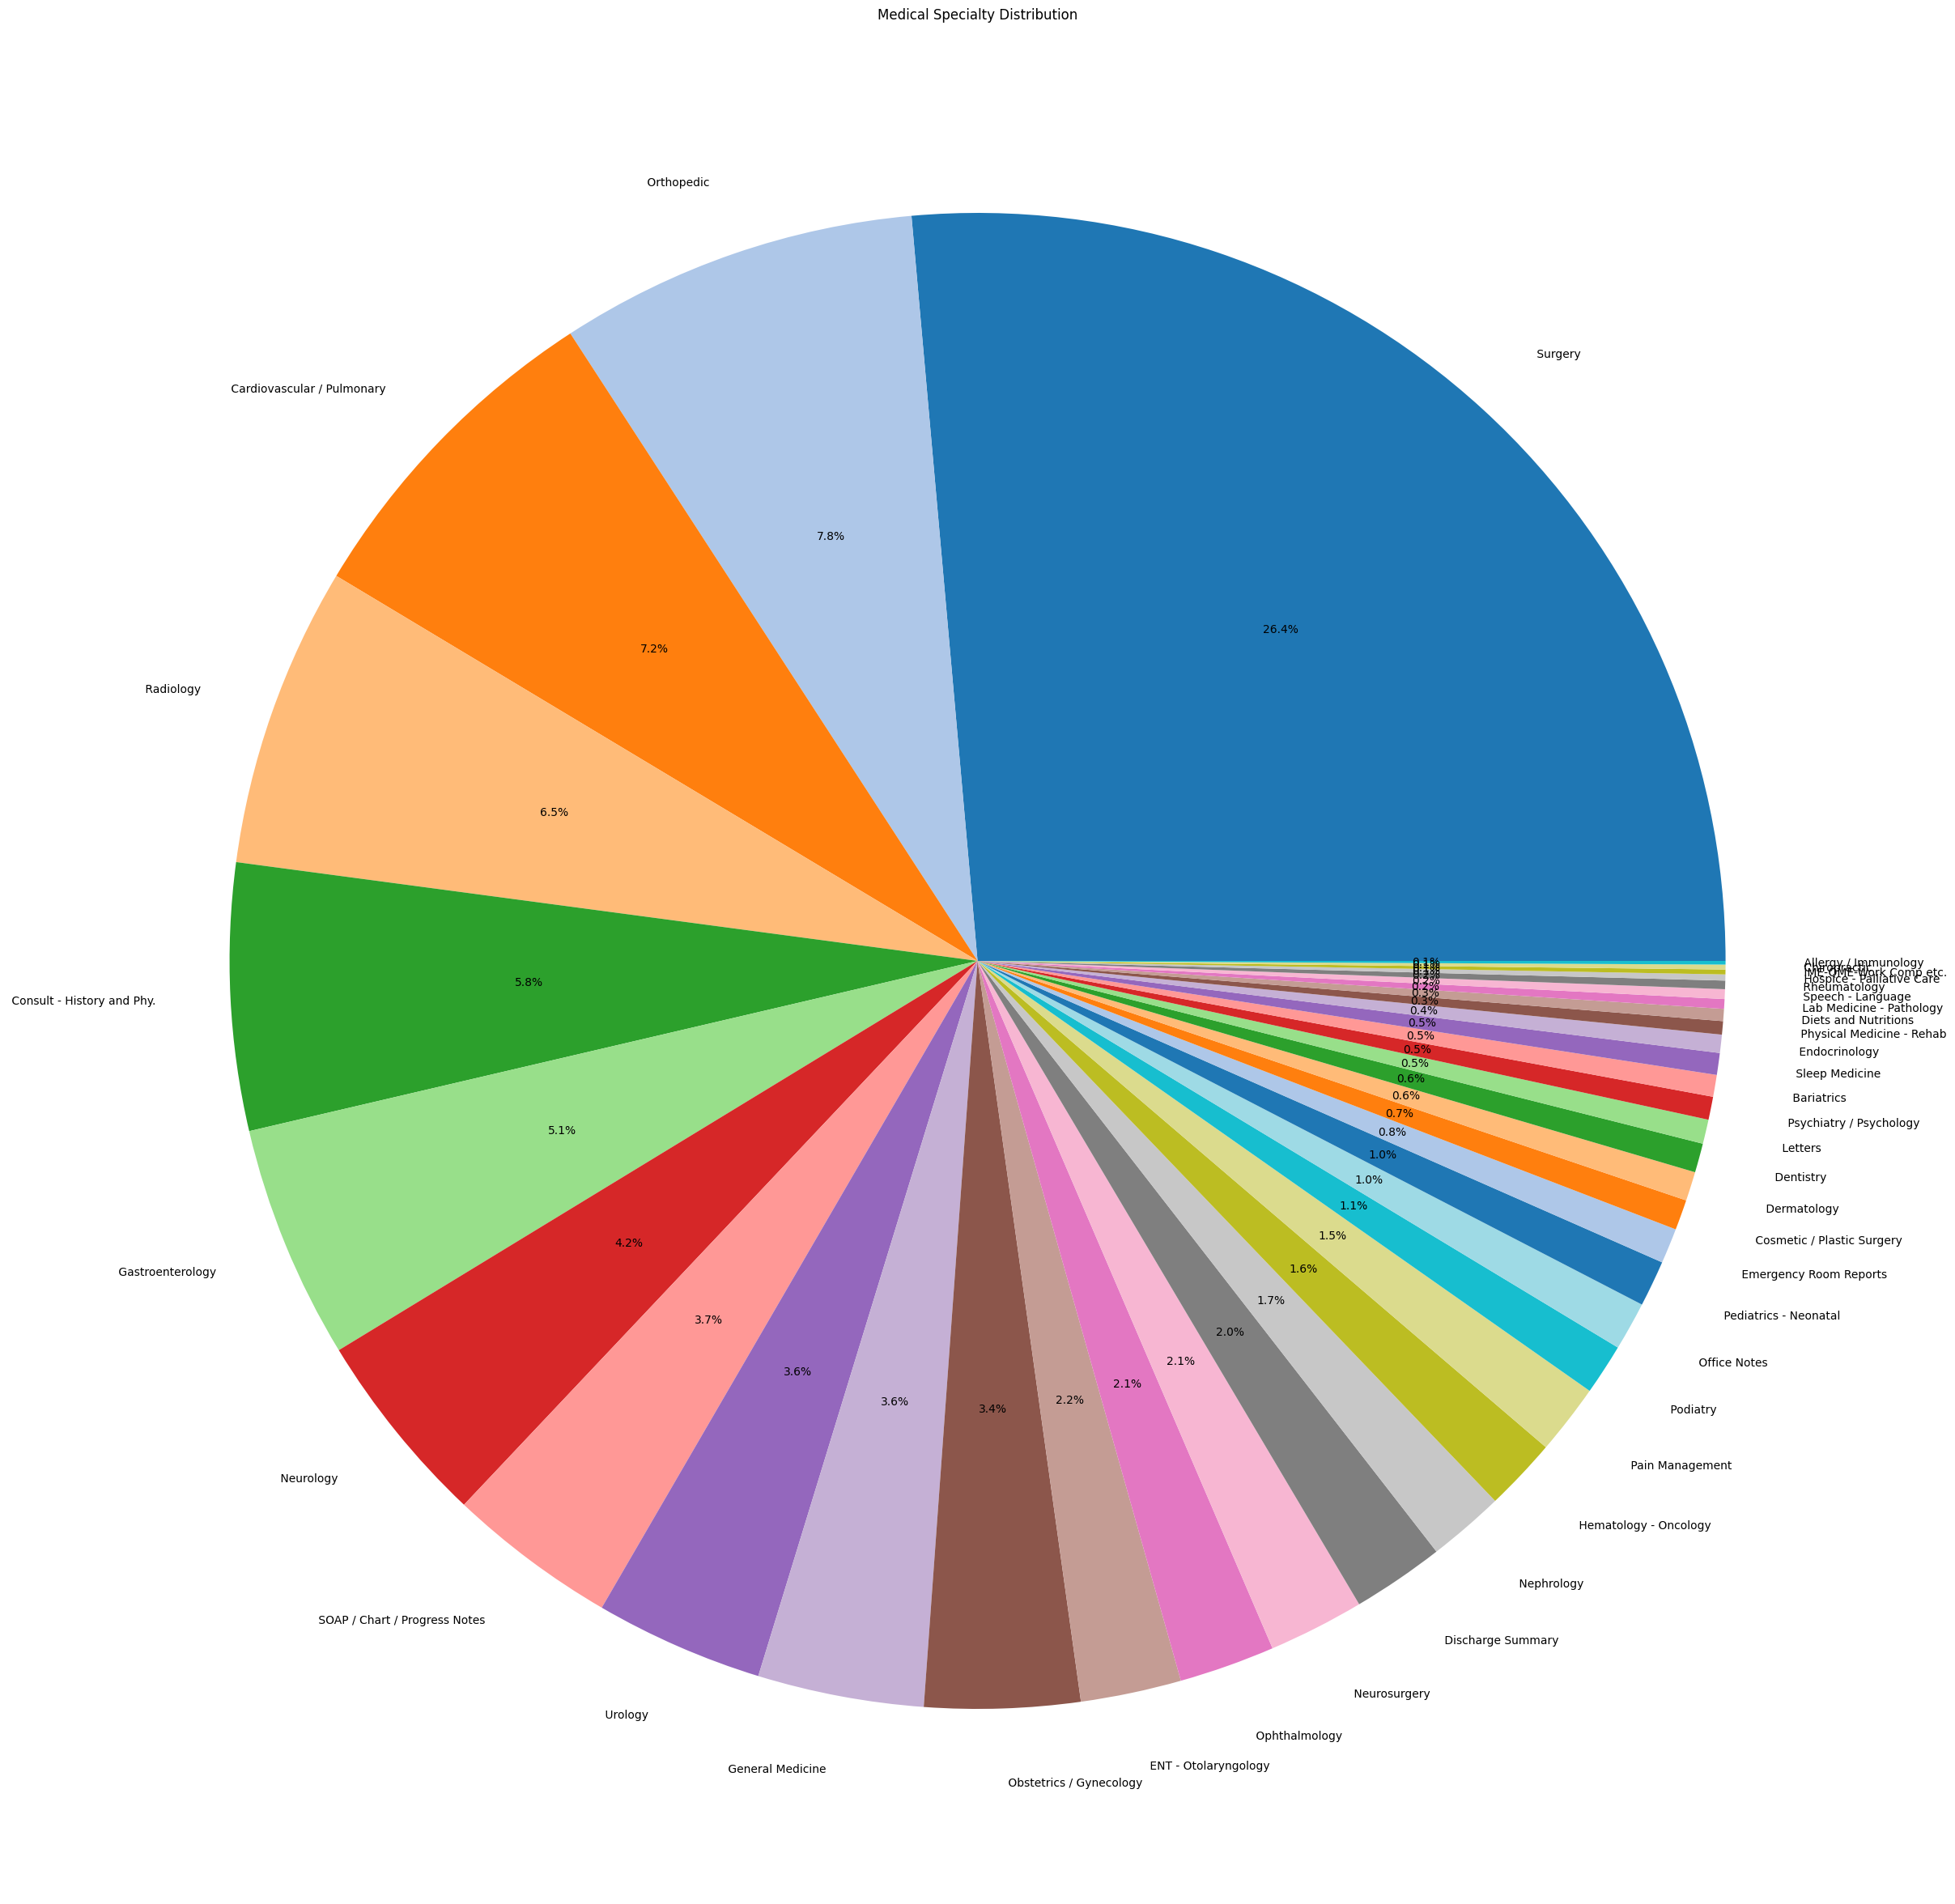

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(30, 30))
plt.pie(df['medical_specialty'].value_counts(), labels=df['medical_specialty'].value_counts().index, autopct='%1.1f%%', colors=plt.get_cmap('tab20').colors)
plt.title('Medical Specialty Distribution')
plt.show()


### Pre-process `transcription` and `keywords` text

**Exercise 5: Create functions to perform below tasks: [0.5 Mark]**

- Convert transcription and keywords text to lowercase
- Remove quotes from transcription and keywords text
- Remove all the special characters/punctuations
- Remove digits from transcription and keywords text
- Remove extra spaces

- **Convert `transcription` and `keywords` text to lowercase**

In [ ]:
# Convert transcription and keywords text to lowercase
# YOUR CODE HERE
def lower_case(text):
    return text.lower()

df['transcription'] = df['transcription'].apply(lower_case)
df['keywords'] = df['keywords'].apply(lower_case)

- **Remove quotes from `transcription` and `keywords` text**

In [ ]:
# Remove quotes from transcription and keywords text
# YOUR CODE HERE
def remove_quotes(text):
    text = text.replace('"', '')
    return text

df['transcription'] = df['transcription'].apply(remove_quotes)
df['keywords'] = df['keywords'].apply(remove_quotes)

- **Remove punctuations**

In [ ]:
# Remove punctuations
# YOUR CODE HERE
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

df['transcription'] = df['transcription'].apply(remove_punctuations)
df['keywords'] = df['keywords'].apply(remove_punctuations)

- **Remove digits from `transcription` and `keywords` text**

string.maketrans(x,y,z)
x: A string containing characters to be replaced.
y: A string containing characters with which x needs to be replaced.
z: A string containing characters to be deleted.

In [ ]:
# Remove digits from transcription and keywords sentences
# YOUR CODE HERE
def remove_digits(text):
    remove_digits = str.maketrans('', '', digits)
    text = text.translate(remove_digits)
    return text

df['transcription'] = df['transcription'].apply(remove_digits)
df['keywords'] = df['keywords'].apply(remove_digits)

- **Remove extra spaces**

In [ ]:
# Remove extra spaces
# YOUR CODE HERE
def remove_extra_spaces(text):
    text = ' '.join(text.split())
    return text

df['transcription'] = df['transcription'].apply(remove_extra_spaces)
df['keywords'] = df['keywords'].apply(remove_extra_spaces)

**Exercise 6: Remove the stopwords from `transcription` text [0.5 Mark]**

- **Remove stopwords**

In [ ]:
# Function to remove the stopwords

def remove_stopwords(text):

    # YOUR CODE HERE
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

In [ ]:
# Remove stopwords from transcriptions
# YOUR CODE HERE
df['transcription'] = df['transcription'].apply(remove_stopwords)


**[OPTIONAL]** Visualize the distribution of word counts in both `transcription` and `keywords` text.

**Hint:**
- Get the text length of each sample
- pd.DataFrame().hist() OR sns.histplot()

<Axes: >

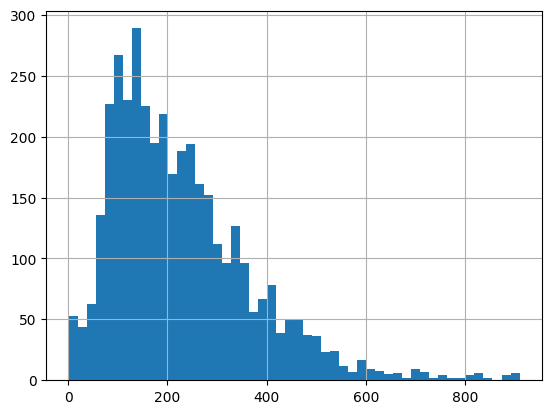

In [ ]:
# Visualize the distribution of word counts
# YOUR CODE HERE

df['transcription'].apply(lambda x: len(x.split())).hist(bins=50)


<Axes: >

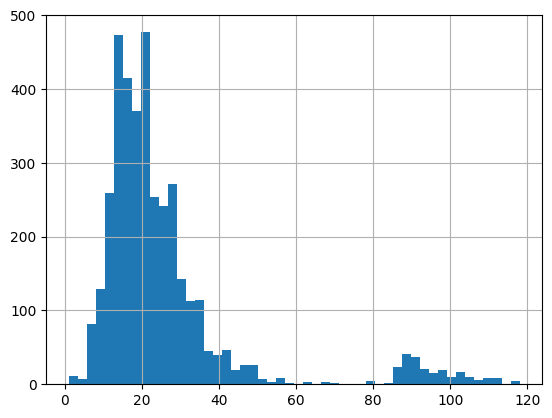

In [ ]:
df['keywords'].apply(lambda x: len(x.split())).hist(bins=50)

### Select the maximum sequence length for both `transcription` and `keywords`

In [ ]:
# Fix the maximum length of the transcript
# Fix the maximum keywords length

max_len_transcript = 250
max_len_keywords = 30

**Exercise 7: Add `'start'` and `'end'` to `keywords` text at the beginning and end respectively [0.5 Mark]**

- 'start' will represent the beginning of output sequence
- 'end' will represent the end of output sequence

In [ ]:
# Add 'start' and 'end' to keywords text
# YOUR CODE HERE
def add_start_end(text):
    return 'start ' + text + ' end'

df['keywords'] = df['keywords'].apply(add_start_end)


In [ ]:
df['keywords'].head()

,keywords
0,start allergy immunology allergic rhinitis allergies asthma nasal sprays rhinitis nasal erythematous allegra sprays allergic end
4993,start allergy immunology chronic glossitis xerostomia probable environmental inhalant allergies probable food allergies environmental inhalant allergies rast allergy testing rast inhalant food all...
4995,start allergy immunology mucous membranes conjunctivitis ad lib kawasaki disease vaccine fever aspirin end
4985,start bariatrics jenny craig medifast nutrisystem richard simmons slimfast tops weight watchers cabbage diet grape fruit diet rouxeny laparoscopic rouxeny gastric bypass weight loss modalities sur...
2,start bariatrics laparoscopic gastric bypass heart attacks body weight pulmonary embolism potential complications sleep study weight loss gastric bypass anastomosis loss sleep laparoscopic gastric...


### Split data into training and testing set

- test_size=0.1
- random_state=0
- shuffle=True

In [ ]:
# YOUR CODE HERE
x_train, x_test, y_train, y_test = train_test_split(df['transcription'], df['keywords'], test_size=0.1, random_state=0, shuffle=True)

### Tokenization and padding

**Exercise 8: Convert the `transcription` and `keywords` text to sequence of integer values, and make them of uniform length [0.5 Mark]**

- Use two tokenizers to tokenize transcription and keywords separately
  
  **Hint:** [Tokenizer()](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer), `.fit_on_texts()`, `.texts_to_sequences()`

- Pad/Truncate both sequences as per their max sequence length specified in above exercises
    - use padding='post', truncating='post'
    - for transcription, (use maxlen= max_len_transcript)
    - for keywords, (use maxlen= max_len_keywords + 1)

  **Hint:** [`pad_sequences(`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer)`sequences= , maxlen= , padding='post', truncating='post')`

- For long keywords sequences, the 'end' token might get truncated
    - replace the last token with the token index of 'end'

- save the vocab size for both sequences

In [ ]:
# Instantiate tokenizer for transcripts
x_tokenizer = Tokenizer(num_words=max_len_transcript)

# Fit on training data
# YOUR CODE HERE
x_tokenizer.fit_on_texts(x_train)
x_word_index = x_tokenizer.word_index
# Convert transcript sequences into integer sequences for both train and val set
# YOUR CODE HERE
train_sequences = x_tokenizer.texts_to_sequences(x_train)
# Add zero padding upto maximum length
# YOUR CODE HERE
x_train_padded = pad_sequences(train_sequences, padding='post', truncating='post', maxlen=max_len_transcript)
# x vocab size
x_voc_size = len(x_tokenizer.word_index) +1
x_voc_size

26940

In [ ]:
# Output the results of our work
print("Word index:\n", x_word_index)
print("\nTraining sequences:\n", train_sequences)
print("\nPadded training sequences:\n", x_train_padded)
print("\nPadded training shape:", x_train_padded.shape)
print("Training sequences data type:", type(train_sequences))
print("Padded Training sequences data type:", type(x_train_padded))

Word index:
 {'patient': 1, 'right': 2, 'left': 3, 'placed': 4, 'procedure': 5, 'well': 6, 'normal': 7, 'using': 8, 'incision': 9, 'performed': 10, 'history': 11, 'used': 12, 'removed': 13, 'skin': 14, 'pain': 15, 'noted': 16, 'room': 17, 'diagnosis': 18, 'time': 19, 'also': 20, 'taken': 21, 'blood': 22, 'without': 23, 'anterior': 24, 'position': 25, 'anesthesia': 26, 'fashion': 27, 'closed': 28, 'made': 29, 'artery': 30, 'x': 31, 'operating': 32, 'area': 33, 'mm': 34, 'vicryl': 35, 'cm': 36, 'preoperative': 37, 'lateral': 38, 'mg': 39, 'yearold': 40, 'general': 41, 'sterile': 42, 'suture': 43, 'posterior': 44, 'tissue': 45, 'upper': 46, 'prepped': 47, 'approximately': 48, 'back': 49, 'obtained': 50, 'good': 51, 'lower': 52, 'draped': 53, 'two': 54, 'given': 55, 'dr': 56, 'evidence': 57, 'cc': 58, 'distal': 59, 'identified': 60, 'stable': 61, 'side': 62, 'small': 63, 'wound': 64, 'patients': 65, 'chest': 66, 'catheter': 67, 'brought': 68, 'loss': 69, 'dissection': 70, 'one': 71, 'surge

In [ ]:
# Instantiate tokenizer for keywords
y_tokenizer = Tokenizer(num_words=max_len_keywords)

# Fit on training data
# YOUR CODE HERE
y_tokenizer.fit_on_texts(y_train)
y_word_index = y_tokenizer.word_index
# Convert keywords sequences into integer sequences for train and val set
# YOUR CODE HERE
test_sequences = y_tokenizer.texts_to_sequences(y_train)
# Add zero padding upto maximum length
# YOUR CODE HERE
y_train_padded = pad_sequences(test_sequences, padding='post', truncating='post', maxlen=max_len_keywords)
# y vocab size
y_voc_size = len(y_tokenizer.word_index) +1
y_voc_size

5933

- **For long keywords sequences, replace the last token with the token index of 'end'**

In [ ]:
print(y_tokenizer.word_index['end'])

1


In [ ]:
y_train.head()

,keywords
842,start surgery ivorlewis esophagogastrectomy jejunostomy thoracotomy duallumen tube chest tubes bovie electrocautery chest endotracheal electrocautery abdomen gastric esophagus tubes vicryl stomach...
1326,start soap chart progress notes abdominal pain nausea dizziness liver disease epigastric pain liver cirrhosis liver abdominal cirrhosis epigastric hepatitis end
643,start surgery veress needle gallbladder laparoscope laparoscopic examination endotracheal intubation laparoscopic cholecystectomy biliary colic abdomen cholecystectomy endotracheal umbilicus lapar...
4370,start consult history and phy anxiety alcohol abuse chest pain digoxin toxicity digoxin overuse atrial fibrillation opioid dependence toxicity dilaudid end
1664,start radiology aspiration deglutition study thin liquids thick liquid semisolids solids modified barium swallow barium swallow dysphagia deglutition end


In [ ]:
# Output the results of our work
print("Word index:\n", y_word_index)
print("\nkeyword sequences:\n", test_sequences)
print("\nPadded keyword sequences:\n", y_train_padded)
print("\nPadded keyword shape:", y_train_padded.shape)
print("keyword sequences data type:", type(test_sequences))
print("Padded keyword sequences data type:", type(y_train_padded))

Word index:
 {'end': 1, 'start': 2, 'of': 3, 'and': 4, 'surgery': 5, 'or': 6, 'to': 7, 'sample': 8, 'the': 9, 'artery': 10, 'pulmonary': 11, 'reports': 12, 'cervical': 13, 'medical': 14, 'transcription': 15, 'any': 16, 'ct': 17, 'anterior': 18, 'disease': 19, 'coronary': 20, 'orthopedic': 21, 'cardiovascular': 22, 'pain': 23, 'chest': 24, 'renal': 25, 'type': 26, 'radiology': 27, 'catheter': 28, 'bilateral': 29, 'laparoscopic': 30, 'heart': 31, 'for': 32, 'nerve': 33, 'history': 34, 'is': 35, 'incision': 36, 'nasal': 37, 'fracture': 38, 'removed': 39, 'date': 40, 'consult': 41, 'by': 42, 'accuracy': 43, 'quality': 44, 'unusual': 45, 'physician': 46, 'be': 47, 'thesetranscribed': 48, 'examples': 49, 'are': 50, 'provided': 51, 'various': 52, 'users': 53, 'andare': 54, 'reference': 55, 'purpose': 56, 'only': 57, 'mthelpline': 58, 'does': 59, 'not': 60, 'certify': 61, 'reportsthese': 62, 'transcribed': 63, 'may': 64, 'include': 65, 'some': 66, 'uncommon': 67, 'formatsthis': 68, 'would': 69

In [ ]:
# Replace the last token with the token index of 'end' for long sequences

# Apply on Train keywords set
# YOUR CODE HERE

# Apply on Validation keywords set
# YOUR CODE HERE


### Positional Embedding

**Exercise 9: Create a class, `PositionalEmbedding` [1 Mark]**

- Use `mask_zero=True`, while defining token embeddings layer

- Make sure to make this layer a mask-generating layer by adding a method `compute_mask()`

In [ ]:
# Using positional encoding to re-inject order information

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):                  # input_dim = (token) vocabulary size,  output_dim = embedding size
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim)            # Q: what is input_dim and output_dim? A: vocab size, embedding dim
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)   # Q: Why input_dim = seq_length?  A: there are seq_len; no. of possible positions
                                                                                                        # Q: What is the vocab for this Embedding layer? A: seq_length
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim


    def call(self, inputs):   # inputs will be a batch of sequences (batch, seq_len)
        length = tf.shape(inputs)[-1]     # lenght will just be sequence length
        positions = tf.range(start=0, limit=length, delta=1) # indices for input to positional embedding
        embedded_tokens = tf.reshape(self.token_embeddings(inputs), (-1, length, self.output_dim))
        embedded_positions = tf.reshape(self.position_embeddings(positions), (-1, length, self.output_dim))
        return layers.Add()([embedded_tokens, embedded_positions])     # ADD the embeddings

    def compute_mask(self, inputs, mask=None):     # makes this layer a mask-generating layer
        if mask is None:
            return None
        return tf.math.not_equal(inputs, 0)        # mask will get propagated to the next layer.

    # When using custom layers, this enables the layer to be reinstantiated from its config dict,
    # which is useful during model saving and loading.
    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config


### Encoder Block

**Exercise 10: Create a class, `TransformerEncoder` [1 Mark]**

- While calling `attention` layer, do not use `attention_mask` parameter

- In Feed forward network, add `Dropout(0.1)` layer after 2 dense layers

- For skip connections, use `tf.keras.layers.Add()` instead of `'+'`

In [ ]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim    # Dimension of embedding. 4 in the dummy example
        self.dense_dim = dense_dim    # No. of neurons in dense layer
        self.num_heads = num_heads    # No. of heads for MultiHead Attention layer
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)    # MultiHead Attention layer
        self.dense_proj = keras.Sequential([layers.Dense(dense_dim, activation="relu"),
                                            layers.Dense(embed_dim),]    # encoders are stacked on top of the other.
                                           )                             # So output dimension is also embed_dim
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    # Call function based on figure above
    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(query=inputs,             # Query: inputs,
                                          value=inputs,             # Value: inputs,
                                          key=inputs,               # Keys: Same as Values by default
                                          attention_mask=mask
                                          )                         # Q: Can you see how this is self attention? A: all args are the same

        proj_input = self.layernorm_1(inputs + attention_output) # LayerNormalization; + Recall cat picture
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)  # LayerNormalization + Residual connection

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config


### Decoder Block

**Exercise 11: Create a class, `TransformerDecoder` [1 Mark]**

- Do not create any separate function to get causal attention mask, just pass `use_causal_mask = True` parameter while calling `attention_1` layer

- While calling `attention_2` layer, do not use `attention_mask` parameter

- In Feed forward network, add `Dropout(0.1)` layer after 2 dense layers

- For skip connections, use `tf.keras.layers.Add()` instead of `'+'`

In [ ]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        # Define the layers. Let's point them out in the diagram
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        # Now we have 2 MultiHead Attention layers - one for self attention and one for generalized attention
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential([layers.Dense(dense_dim, activation="relu"),
                                            layers.Dense(embed_dim),]
                                           )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True   #ensures that the layer will propagate its input mask to its outputs;

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1])) # sequence_length == input_shape[1]
        mult = tf.concat([tf.expand_dims(batch_size, -1),
                          tf.constant([1, 1], dtype=tf.int32)],
                         axis=0
                         )
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None): # two inputs: decoder i/p and encoder o/p
        causal_mask = self.get_causal_attention_mask(inputs)
        # print(f"*** test: mask = {causal_mask}")
        padding_mask = None

        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask) # union of 0s
            # print(f"**** test padding mask: {padding_mask}")

        attention_output_1 = self.attention_1(query=inputs,                     # Q: What kind of attention?  A: self attention
                                              value=inputs,
                                              key=inputs,
                                              attention_mask=causal_mask        # Q: What will the causal_mask do? A: makes attention score of a query independent of future tokens
                                              )

        attention_output_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(query=attention_output_1,         # Q: Is this self attention? A: No. This is generalised attention
                                              value=encoder_outputs,            # Key and Value coming from encoder
                                              key=encoder_outputs,
                                              attention_mask=padding_mask,
                                              )

        attention_output_2 = self.layernorm_2(attention_output_1 + attention_output_2)
        proj_output = self.dense_proj(attention_output_2)
        return self.layernorm_3(attention_output_2 + proj_output)


### Build Transformer model

**Exercise 12: Create a transformer model with below points: [1 Mark]**

- Use the respective vocabulary size for PositionalEmbedding of encode and decoder inputs

- Add `Dropout(0.1)` layers after both encoder and decoder PositionalEmbedding layers

- Do not use `activation="softmax"` for the last dense classification layer (You will be required to create a custom loss, and metric in the next stage.)

- Add a stack of 4 encoder blocks and 4 decoder blocks to your transformer

In [ ]:
# Create transformer model

embed_dim = 256
dense_dim = 2048
num_heads = 8

encoder_inputs = keras.Input(shape=(None,))

# YOUR CODE HERE ...
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs) # Q: First arg acts like a 'vocabulary' for pos embedding layer
x = layers.Dropout(0.5)(x)
encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x) #Q: What are these arguments? A: embedding dimension, no. of neurons in dense layer, no. of head in multi-head attention layer


decoder_inputs = keras.Input(shape=(None,))

# YOUR CODE HERE ...
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = layers.Dropout(0.5)(x)
x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs) # Q: What are the call arguments in the picture?


decoder_outputs = layers.Dense(y_voc_size)(x)

transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
transformer.summary()

## Model Compilation and Training [1 Mark]

**Exercise 13: Set up the optimizer**

Refer [here](https://www.tensorflow.org/text/tutorials/transformer#set_up_the_optimizer) for the following steps:

- Use the Adam optimizer with a custom learning rate scheduler

- Instantiate the Adam optimizer with custom learning rate

In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


In [ ]:
# Instantiate the Adam optimizer with custom learning rate
# YOUR CODE HERE
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

**Exercise 14: Set up the loss and metrics**

- Apply a padding mask while calculating the loss with cross-entropy loss function as demonstrated [here](https://www.tensorflow.org/text/tutorials/transformer#set_up_the_loss_and_metrics).  

In [ ]:
def masked_loss(label, pred):
  mask = label != 0
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')
  loss = loss_object(label, pred)

  mask = tf.cast(mask, dtype=loss.dtype)
  loss *= mask

  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def masked_accuracy(label, pred):
  pred = tf.argmax(pred, axis=2)
  label = tf.cast(label, pred.dtype)
  match = label == pred

  mask = label != 0

  match = match & mask

  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)


**Exercise 15: Compile transformer model with custom optimizer, loss, and metric & perform training [0.5 Mark]**

- Use [*transcription sequences*, and *keywords sequences(shifted right)*] as input to transformer

- Train model using colab's GPU runtime with batch_size=32, and epochs=30. (It might take one minute per epoch with GPU)

**Hint:** Check if the training code is running without any errors with CPU runtime, later switch to GPU runtime for faster training. Once trained, save the model weights, and download into your system for later use.

In [ ]:
# Compile

# YOUR CODE HERE
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [ ]:
# Train

# YOUR CODE HERE

transformer.fit(train_batches,
                epochs=20,
                validation_data=val_batches)

### Save model weights

In [ ]:
!mkdir my_model_weights

In [ ]:
# Save model weights
# It will create a '.weights.h5' file which can be downloaded into your system from colab

transformer.save_weights('my_model_weights/my_weights.weights.h5')

In [ ]:
# OR
# Make a zip file, which also can be downloaded into your system from colab

!zip -r 'my_model_weights.zip' 'my_model_weights'

### Load model weights

Whenever you need to use this trained model weights:
* use the model architecture to create exact same model
* then load the trained weights directly using below code

In [ ]:
# To load model weights
#transformer.load_weights('my_model_weights/my_weights.weights.h5')

## Run Inference

**Exercise 16: Create a function to extract keywords, given transcription text as input [1 Mark]**

- Encode the input sentence using the Transcription tokenizer. This is the encoder input
- Initialize decoder input with the 'start' token
- The decoder then outputs the predictions by looking at the encoder output and its own output (self-attention).
- Concatenate the predicted token to the decoder input and pass it to the decoder repeatedly
- Make decoder predict the next token based on the previous tokens it has predicted

In [ ]:
def extract_keywords(sentence, transformer=transformer):

    """ Takes an input sentence, and transformer. Returns extracted keywords. """

    # Convert input sentence into integer sequence (Note that tokenizer.texts_to_sequences() take list of text as input)
    ip_tokens = # YOUR CODE HERE

    # Add zero padding upto maximum length transcription
    ip_tok_seq = # YOUR CODE HERE

    # Create a decoder sequence with 'start' token index
    dec_tok_seq = np.array([y_tokenizer.word_index['start']])

    # Variable to store the output text string
    keyword_sentence = ''

    for i in range(max_len_keywords):

        # Get output logits from transformer
        pred = transformer([ip_tok_seq.reshape(1,-1), dec_tok_seq.reshape(1, -1)], training=False)
        pred = pred[:, -1:, :]

        # Select the index with max value from 'pred' to get the output token index
        token = # YOUR CODE HERE

        # Convert output token to word
        word = y_tokenizer.index_word[token]

        # End the loop if word is 'end'
        # YOUR CODE HERE

        # Append 'token' to dec_tok_seq
        dec_tok_seq = np.append(dec_tok_seq, token)

        # Append 'word' to keyword sentence
        # YOUR CODE HERE

    return keyword_sentence.strip()


In [ ]:
# Predict keywords for a sample input

# YOUR CODE HERE

## Gradio Implementation [OPTIONAL]

Gradio is an open-source python library that allows us to quickly create easy-to-use, customizable UI components for our ML model, any API, or any arbitrary function in just a few lines of code. We can integrate the GUI directly into the Python notebook, or we can share the link with anyone.

In [ ]:
!pip -qq install gradio

In [ ]:
import gradio

In [ ]:
# Input from user
in_transcript = gradio.Textbox(lines=10, placeholder=None, value="transcription", label='Enter Transcription Text')

# Output prediction
out_keywords = gradio.Textbox(type="text", label='Extracted Keywords')


# Gradio interface to generate UI
iface = gradio.Interface(fn = extract_keywords,
                         inputs = [in_transcript],
                         outputs = [out_keywords],
                         title = "Keywords Extraction",
                         description = "Using transformer model, trained from scratch",
                         allow_flagging = 'never')

iface.launch(share = True)

Click on the link generated above to see UI.